<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_1_Classification_Basics/18_1_5_creditcardfraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification: Part 5
## Credit Card Fraud Detection
**Author:** Brad Sheese

---

A credit card network clears tens of thousands of transactions a minute, and only a tiny fraction — well under 1% — are fraudulent. That extreme imbalance breaks the tools we have leaned on so far: a model that simply labels every transaction legitimate scores 99.8% accuracy while catching zero fraud. This notebook builds the evaluation toolkit that still works when the thing you care about is this rare.

### Learning Objectives
By the end of this notebook you will be able to:
1. Explain why accuracy and ROC AUC become misleading when class imbalance is extreme, and demonstrate this with actual plots.
2. Use the Precision-Recall curve as the primary evaluation tool for severe class imbalance.
3. Apply the F-Beta score to optimize a threshold that weights recall over precision.
4. Generate out-of-fold (OOF) probabilities on training data to select a threshold without contaminating the test set.
5. Compare four threshold selection strategies — default, Youden's J, F-Beta optimal, and cost-optimal — on a held-out test set.
6. Translate model decisions into dollar costs using explicit, defensible cost assumptions.

## Credit Card Fraud Detection Dataset

**Data Source:** [OpenML](https://www.openml.org/d/1597) - Original dataset from Kaggle, originally collected by Worldline and the Machine Learning Group at Université Libre de Bruxelles (ULB)

**Outcome Variable:** `Class` - Binary: 0 = legitimate transaction, 1 = fraudulent transaction

**Features:**
- **Amount:** Transaction amount
- **V1-V28:** Anonymized features obtained via PCA transformation (original sensitive features were transformed to protect customer identities)

*Note: The original Kaggle dataset also includes a `Time` feature (seconds elapsed since the first transaction). The OpenML version used here does not include `Time`.*

The dataset contains 284,807 transactions with only 492 frauds (0.172% fraud rate), making it extremely imbalanced.

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold, cross_val_score, cross_val_predict,
    train_test_split
)
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report, roc_curve, auc,
    precision_recall_curve, make_scorer
)
import xgboost as xgb

In [2]:
# get the data, create a dataframe
creditcard = fetch_openml(name='creditcard', version=1, as_frame=True)
df = creditcard.frame

# Convert Class from category to int (OpenML loads it as categorical)
df['Class'] = df['Class'].astype(int)

In [3]:
# check data (missing, dtype) - this has already been cleaned up
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 30 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   V1      284807 non-null  float64
 1   V2      284807 non-null  float64
 2   V3      284807 non-null  float64
 3   V4      284807 non-null  float64
 4   V5      284807 non-null  float64
 5   V6      284807 non-null  float64
 6   V7      284807 non-null  float64
 7   V8      284807 non-null  float64
 8   V9      284807 non-null  float64
 9   V10     284807 non-null  float64
 10  V11     284807 non-null  float64
 11  V12     284807 non-null  float64
 12  V13     284807 non-null  float64
 13  V14     284807 non-null  float64
 14  V15     284807 non-null  float64
 15  V16     284807 non-null  float64
 16  V17     284807 non-null  float64
 17  V18     284807 non-null  float64
 18  V19     284807 non-null  float64
 19  V20     284807 non-null  float64
 20  V21     284807 non-null  float64
 21  V22     284807 non-nu

In [4]:
# verifying extreme imbalance
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

In [5]:
# get descriptives for features
df.iloc[:,:-1].describe().T.iloc[:,1:].round(2).sort_index().head(10)

,mean,std,min,25%,50%,75%,max
Amount,88.35,250.12,0.00,5.60,22.00,77.16,25691.16
V1,0.00,1.96,-56.41,-0.92,0.02,1.32,2.45
V10,0.00,1.09,-24.59,-0.54,-0.09,0.45,23.75
V11,0.00,1.02,-4.80,-0.76,-0.03,0.74,12.02
V12,-0.00,1.00,-18.68,-0.41,0.14,0.62,7.85
V13,0.00,1.00,-5.79,-0.65,-0.01,0.66,7.13
V14,0.00,0.96,-19.21,-0.43,0.05,0.49,10.53
V15,0.00,0.92,-4.50,-0.58,0.05,0.65,8.88
V16,0.00,0.88,-14.13,-0.47,0.07,0.52,17.32
V17,-0.00,0.85,-25.16,-0.48,-0.07,0.40,9.25


### Reading This Plot

The violin plot compares the `Amount` distribution between legitimate (0) and fraudulent (1) transactions. Amounts above $2,500 are excluded to prevent a few very large transactions from compressing the rest of the plot.

Two things stand out:

- **The distributions overlap heavily.** Fraudsters do not exclusively target large or small amounts — both classes span a wide, similar range. Transaction amount alone is not a reliable signal for detecting fraud.
- **The fraud median is slightly lower.** Fraudsters may keep individual transaction amounts modest to avoid rule-based alerts. But the overlap is so large that this difference alone would not allow reliable classification.

This is why V1–V28 carry most of the predictive power. Those PCA-transformed features encode the original transaction patterns (timing, merchant category, card behavior, etc.) in a way that is far more discriminating than raw dollar amount. The feature importance plot below will confirm which of those components matter most.

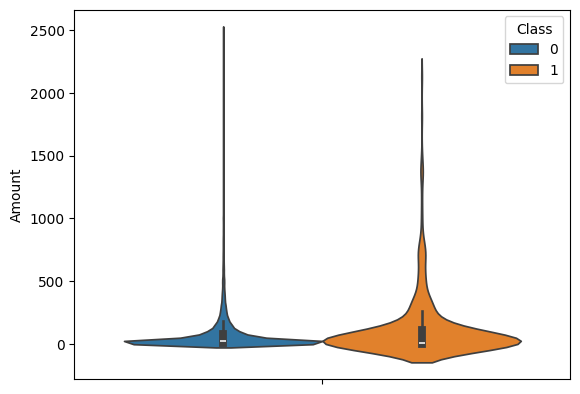

In [6]:
# check out amount as it relates to class
sns.violinplot(data=df[df['Amount'] < 2500], y='Amount', hue='Class')
plt.show()

## Prepare the Data for XGBoost

* **Numeric targets?** XGBoost requires numeric encodings for the labels (binary encoding in this case). This is already done. 0 is not-fraud, 1 is fraud.
* **Categorical Features?** XGBoost can now handle categorical data directly, so you don't have to one-hot encode anymore. With this particular data set there are no categorical features to worry about anyway.
* **Feature Scaling?** XGBoost is a tree-based model and does not require feature scaling. However, note that `Amount` has a very different scale than V1-V28 (which were already standardized via PCA). If you were using a distance-based or gradient-based model (e.g., Logistic Regression, SVM, Neural Networks), you would need to scale `Amount` first, but we are using a tree-based model so we don't need to.
* **Stratified split?** Our imbalance is so extreme it is absolutely essential we use stratified splits.


In [7]:
X = df.iloc[:,:-1]
y = df['Class']

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
                                      X,
                                      y,
                                      test_size=0.3,
                                      random_state=42,
                                      stratify=y)

print(f"Original features: {X.shape[1]}")
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set class ratio: {y_test.mean():.1%} bad, {(1-y_test.mean()):.1%} good")

Original features: 29
Training set size: 199364
Test set class ratio: 0.2% bad, 99.8% good


## Decisions for Initial XGBoost Model

* `n_estimators`, `max_depth`, `learning_rate`: Standard starting values — we will grid search these in the next notebook (Notebook 6).
* `eval_metric`: Controls what XGBoost **monitors** during boosting rounds (used for logging and early stopping). It does **not** change the training loss function — that is controlled by the `objective` parameter. Switching to a different `eval_metric` changes the signal XGBoost watches as it trains, not what it optimizes. Our options here:
  * `error`: Classification error rate.
  * `logloss`: Log loss, which produces well-calibrated probabilities. This is what we relied on in the earlier notebooks.
  * `auc`: Area under the ROC curve — can give a falsely optimistic training signal on imbalanced datasets for the same reason the ROC curve itself misleads (see below).
  * `aucpr`: Area under the Precision-Recall curve — evaluates the model strictly on its ability to separate the minority class. We use this here because our dataset is so imbalanced (0.17% fraud) that AUC would provide a misleading training signal.

  Note: without early stopping enabled, `eval_metric` is informational only during training. Its main practical importance is when you stop training when the monitored metric plateaus on a validation set.

In [8]:
# We don't use scale_pos_weight here to address the imbalance,
# instead we will start with the default and then look for an optimal decision point

# Instantiate and train the XGBoost model
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    eval_metric='aucpr',
    random_state=42,
)
model.fit(X_train, y_train)

# Get probabilities for the positive class (Fraud)
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print('Model training complete.')

Model training complete.


## Feature Importance

Even though V1–V28 are anonymized PCA components (we cannot interpret what they represent in the real world), examining feature importance is still useful here for two reasons.

First, it reinforces the *skill* of generating and reading importance plots — something you will apply constantly on interpretable datasets. Second, on real fraud systems, even anonymous features carry actionable information: if V14 and V4 dominate importance, a data engineer with access to the original pre-PCA variables can trace which raw transaction attributes those components encode and investigate whether they are robust signals or brittle artifacts of the training period.

What you *cannot* do here is say 'high V14 → more likely fraud' without additional analysis. The importance score tells you the feature matters; it says nothing about direction or magnitude of effect.

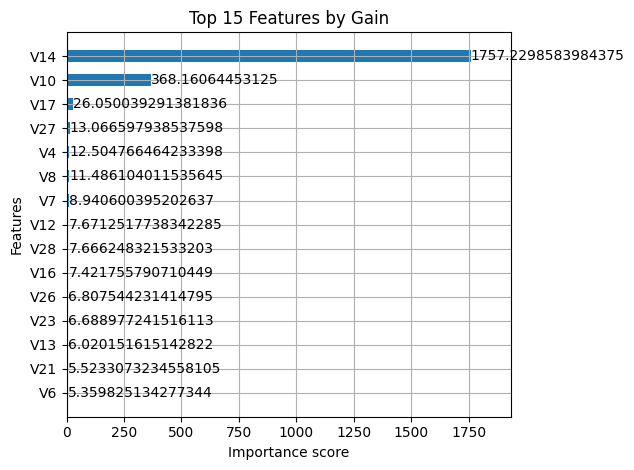

Note: V1-V28 are anonymized PCA components, so we can't interpret what they represent.
However, we can see which transformed features are most predictive of fraud.


In [9]:
# Feature importance plot
xgb.plot_importance(model, max_num_features=15, importance_type='gain', height=0.5)
plt.title('Top 15 Features by Gain')
plt.tight_layout()
plt.show()

print("Note: V1-V28 are anonymized PCA components, so we can't interpret what they represent.")
print("However, we can see which transformed features are most predictive of fraud.")

## Confusion Matrix

--- Confusion Matrix Breakdown ---
True Negatives  (TN) — Correctly Identified Non-Fraud: 85290
True Positives  (TP) — Correctly Identified Fraud:  110
False Positives (FP) — False Alarms / Type I:     5
False Negatives (FN) — Missed Fraud / Type II: 38


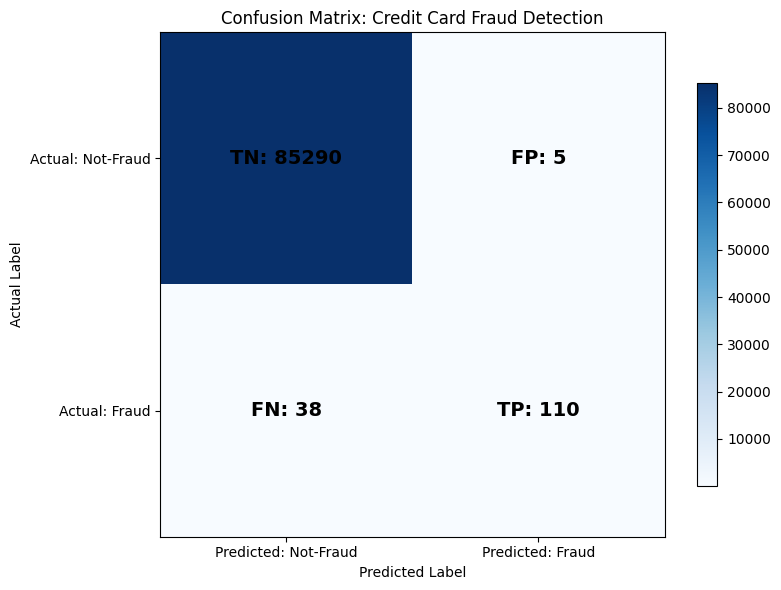

In [10]:
# Generate the matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"--- Confusion Matrix Breakdown ---")
print(f"True Negatives  (TN) — Correctly Identified Non-Fraud: {tn}")
print(f"True Positives  (TP) — Correctly Identified Fraud:  {tp}")
print(f"False Positives (FP) — False Alarms / Type I:     {fp}")
print(f"False Negatives (FN) — Missed Fraud / Type II: {fn}")

# Visualize with labeled cells
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted: Not-Fraud', 'Predicted: Fraud'])
ax.set_yticklabels(['Actual: Not-Fraud', 'Actual: Fraud'])
ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')
ax.set_title('Confusion Matrix: Credit Card Fraud Detection')

# Add labels with both count and terminology
labels = [
    [f'TN: {tn}', f'FP: {fp}'],
    [f'FN: {fn}', f'TP: {tp}']
]
for i in range(2):
    for j in range(2):
        ax.text(j, i, labels[i][j], ha='center', va='center', fontsize=14, fontweight='bold')

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

In [11]:
print(classification_report(y_test, y_pred, target_names=['Not-Fraud (0)', 'Fraud (1)']))

               precision    recall  f1-score   support

Not-Fraud (0)       1.00      1.00      1.00     85295
    Fraud (1)       0.96      0.74      0.84       148

     accuracy                           1.00     85443
    macro avg       0.98      0.87      0.92     85443
 weighted avg       1.00      1.00      1.00     85443



### Reading This Report

With 0.17% fraud and 99.83% legitimate transactions, three things are immediately true:

- **Accuracy of 1.00 is the accuracy paradox at its most extreme.** A model that predicted "Not Fraud" for every single transaction would also score ~99.8% accuracy. This number tells us nothing.
- **Weighted average is equally useless.** With 99.83% legitimate transactions dominating the support counts, the weighted average is mathematically indistinguishable from overall accuracy — it cannot reflect minority-class performance at all.
- **The only honest summary statistics are the Fraud (1) row and the macro average.** Precision of 0.96 and recall of 0.74 on the Fraud row tell the real story: when the model flags a transaction it is almost always right, but it misses roughly 1 in 4 actual fraud cases. That 26% miss rate is where the rest of this notebook focuses.

## Looking for an Optimal Decision Point
Let's start by visualizing the performance of the model using the current default decision point.


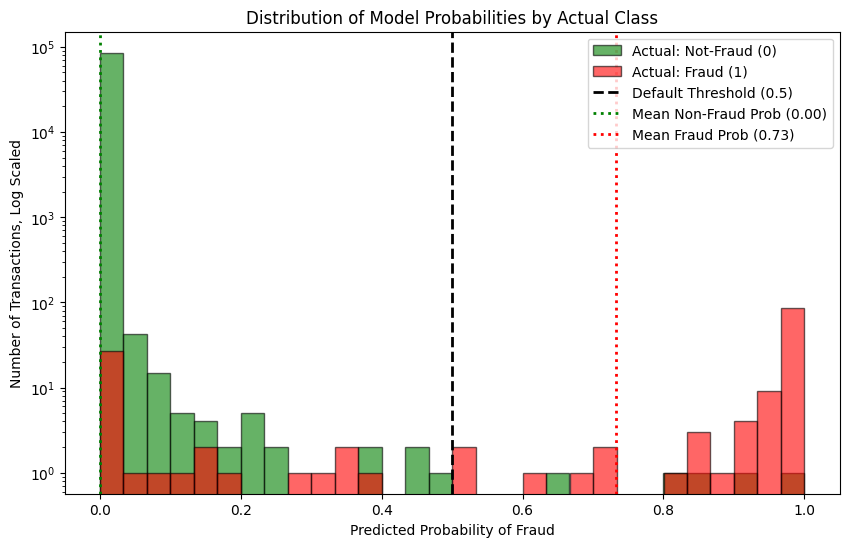


Overlap Analysis:
  25.7% of actual fraudulent transactions scored below 0.5 (missed cases / false negatives)
  0.0% of legitimate transactions scored above 0.5 (false alarms / false positives)


In [12]:
# Calculate overlap statistics
fn_rate = ((y_proba[y_test==1] < 0.5).sum() / (y_test==1).sum()) * 100
fp_rate = ((y_proba[y_test==0] >= 0.5).sum() / (y_test==0).sum()) * 100

fig, ax = plt.subplots(figsize=(10, 6))

# Plot overlapping histograms by actual class
ax.hist(y_proba[y_test==0], bins=30, alpha=0.6, label='Actual: Not-Fraud (0)', color='green', edgecolor='black')
ax.hist(y_proba[y_test==1], bins=30, alpha=0.6, label='Actual: Fraud (1)', color='red', edgecolor='black')
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Default Threshold (0.5)')

# Add mean probability lines
mean_good = y_proba[y_test==0].mean()
mean_bad = y_proba[y_test==1].mean()
ax.axvline(x=mean_good, color='green', linestyle=':', linewidth=2, label=f'Mean Non-Fraud Prob ({mean_good:.2f})')
ax.axvline(x=mean_bad, color='red', linestyle=':', linewidth=2, label=f'Mean Fraud Prob ({mean_bad:.2f})')

ax.set_xlabel('Predicted Probability of Fraud')
ax.set_ylabel('Number of Transactions, Log Scaled')
ax.set_title('Distribution of Model Probabilities by Actual Class')
ax.set_yscale('log') # Changed to y-axis log scale
ax.legend()
plt.show()

print(f"\nOverlap Analysis:")
print(f"  {fn_rate:.1f}% of actual fraudulent transactions scored below 0.5 (missed cases / false negatives)")
print(f"  {fp_rate:.1f}% of legitimate transactions scored above 0.5 (false alarms / false positives)")

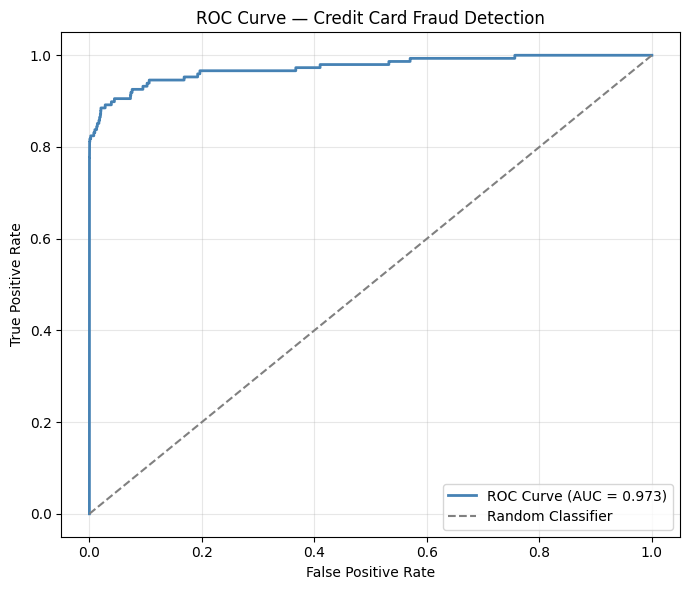

ROC AUC: 0.973

The curve hugs the top-left corner and the AUC looks impressive.
But with 85,000+ legitimate transactions, even thousands of false alarms barely move the FPR.
The massive pool of true negatives in the denominator (FPR = FP / (FP + TN)) absorbs false positives.
This is the deceptive optimism the next section describes.


In [13]:
# ROC Curve — plot it first so you can see the "deceptively optimistic" problem directly
fpr_roc, tpr_roc, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr_roc, tpr_roc)

plt.figure(figsize=(7, 6))
plt.plot(fpr_roc, tpr_roc, color='steelblue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Credit Card Fraud Detection')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc:.3f}")
print()
print("The curve hugs the top-left corner and the AUC looks impressive.")
print("But with 85,000+ legitimate transactions, even thousands of false alarms barely move the FPR.")
print("The massive pool of true negatives in the denominator (FPR = FP / (FP + TN)) absorbs false positives.")
print("This is the deceptive optimism the next section describes.")

While the classification report gave you the final scores, this graph shows you why we got those scores and how confident the model is.

### 1. The Power of Separation
*   **The Green Peak (Not-Fraud):** The model is incredibly good at identifying legitimate transactions. Almost all green samples are clustered at 0.0, meaning the model is nearly 100% certain they aren't fraud.
*   **The Red Distribution (Fraud):** This is much more spread out. While many fraud cases are correctly pushed to the right (near 1.0), a significant number are scattered between 0.0 and 0.5. This is where our model struggles.

### 2. Understanding the Log Scale (Y-Axis)
The Y-axis is Log Scaled ($10^0, 10^1, 10^2$, etc.). This is necessary because there are ~85,000 "Not-Fraud" cases and only 148 "Fraud" cases.
*   If this were a normal scale, the red bars would be invisible because they are so small compared to the green mountain at 0.0.
*   The fact that you see green bars at 0.1, 0.2, and 0.3 on a log scale means there are actually very few of them (likely just 1 to 10 transactions), which explains why the precision is so high (0.96).

### 3. The "Missed" Fraud (Recall)
Look at the red bars to the left of the black dashed line (0.5 threshold):
*   Every red bar to the left of 0.5 represents a False Negative (actual fraud that your model called "Not-Fraud").
*   There is a noticeable cluster of red bars near 0.0. These are "stealthy" fraud cases that look exactly like legitimate transactions to your model. This is what caused your Recall to be 0.74.

### 4. The Mean Probabilities
*   **Mean Non-Fraud Prob (0.00):** This is a perfect result. It shows the model almost never "doubts" a legitimate transaction.
*   **Mean Fraud Prob (0.73):** While 0.73 is decent, it is "pulled down" by the fraud cases the model scored low. In a perfect world we would want this mean to be closer to 1.0.


This graph suggests we could easily improve our Recall by moving the threshold.
If we move the threshold (black line) to 0.1, we would catch almost all of the red bars (Fraud), significantly increasing our Recall. However, because there are some green bars (Not-Fraud) between 0.1 and 0.5, our Precision would drop slightly. However, because the green counts are so low there (notice they are at the bottom of the log scale), you would likely only add a few dozen "False Alarms" while catching nearly all the fraud.

**Summary so far:** Our model is doing a great job of separating the classes, but it is currently "playing it safe" by using a 0.5 threshold. For fraud detection, we likely want to be more aggressive (move the threshold left).

### Why the ROC Curve Misleads Here — Let's Verify It

The ROC AUC can be dangerously optimistic on extremely imbalanced datasets. The reason: ROC AUC relies on the False Positive Rate, calculated as FP / (FP + TN). With ~99.8% legitimate transactions, the TN count is enormous. Even if the model generates thousands of false alarms, the FPR stays artificially small because the denominator is so large — the true negatives swamp the false positives.

Rather than just asserting this, let's plot the ROC curve first so you can see exactly what "deceptively optimistic" looks like. Then we'll plot the Precision-Recall curve to compare.

### What the ROC Curve Shows — and Why We Move Past It

The ROC AUC printed above will look impressive — likely near 0.97 or higher. That is exactly the problem. With 85,295 legitimate transactions in the test set, even a model that generates hundreds of false alarms barely moves the FPR. The curve hugs the top-left corner not because the model is outstanding, but because true negatives are so abundant that FPR is almost impossible to drive up.

The Precision-Recall curve ignores true negatives entirely. It only asks: of the transactions we flagged as fraud, how many actually were? And of all real fraud, how many did we catch? If we start flagging innocent transactions to catch more fraud, precision drops immediately — there is no massive TN pool to absorb the damage. This makes the PR curve the honest evaluation tool for this dataset.

---

## F-Beta Score

The Precision-Recall curve shows the full trade-off — but it does not tell us which point to choose. The F-Beta score is a formula that lets you pick a specific operating point by specifying how much more you care about recall than precision.

$$F_\beta = (1 + \beta^2) \cdot \frac{\text{precision} \cdot \text{recall}}{\beta^2 \cdot \text{precision} + \text{recall}}$$

The $\beta^2$ term in the denominator acts as a weight on precision. When $\beta > 1$, precision is scaled up in the denominator, making the overall score more sensitive to recall — a model must improve recall to score higher, even at some cost to precision. When $\beta < 1$, the weighting reverses.

Common settings:
- **F1 Score ($\beta = 1$):** Precision and recall weighted equally — reduces to the standard F1 from notebook 2.
- **F2 Score ($\beta = 2$):** Recall weighted **4×** higher than precision. Business logic: missing a fraud case costs far more than a false alarm — catch every fraudster, even if a few good customers are blocked.
- **F0.5 Score ($\beta = 0.5$):** Precision weighted **4×** higher than recall. Business logic: false alarms are damaging customer trust — only flag transactions we are very confident about.

As in Notebook 4, we generate out-of-fold (OOF) probabilities on the training set to find the optimal threshold without ever touching the test set.

In [14]:
# Generate Out-of-Fold (OOF) probabilities using the training set.
# We use cross_val_predict to simulate predictions on unseen data.
# This allows us to tune thresholds WITHOUT touching the test set.
print("Generating Out-of-Fold probabilities (this may take a moment)...")
oof_train_probs = cross_val_predict(model, X_train, y_train, cv=5, method='predict_proba')[:, 1]
print("OOF probabilities generated.")

Generating Out-of-Fold probabilities (this may take a moment)...


OOF probabilities generated.


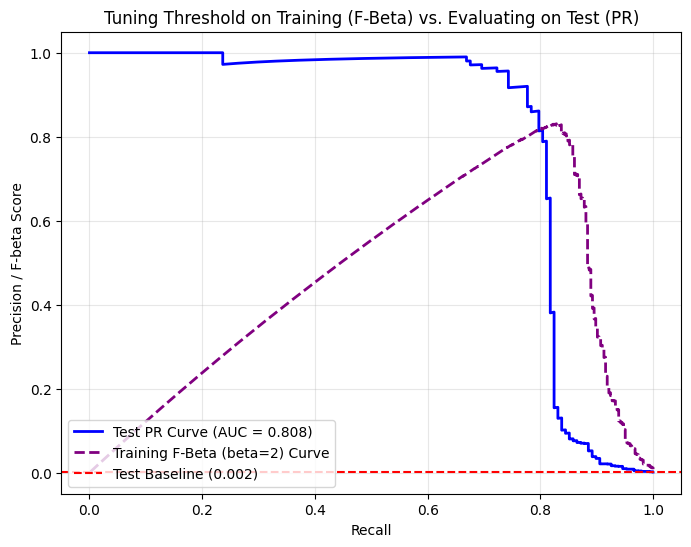

Tuned Threshold (from Training F-Beta): 0.086
Test PR AUC = 0.808


In [15]:
# Calculate precision and recall values across various probability thresholds using OOF training probabilities.
# This ensures we tune our threshold on data the model hasn't "seen" without using the test set.
precision_train, recall_train, thresholds_train = precision_recall_curve(y_train, oof_train_probs)

# Calculate F-beta scores on training data
beta = 2  # Prioritize recall (beta > 1)
f_beta_scores_train = (1 + beta**2) * (precision_train * recall_train) / (beta**2 * precision_train + recall_train)
f_beta_scores_train = np.nan_to_num(f_beta_scores_train)

# Find the optimal threshold for F-beta based on training data
best_f_beta_idx = np.argmax(f_beta_scores_train[:-1])
best_threshold_f_beta = thresholds_train[best_f_beta_idx]

# Now calculate the PR Curve for the TEST set for comparison (evaluation only)
precision_test, recall_test, thresholds_test = precision_recall_curve(y_test, y_proba)
pr_auc_test = auc(recall_test, precision_test)

plt.figure(figsize=(8, 6))
plt.plot(recall_test, precision_test, color='blue', lw=2, label=f'Test PR Curve (AUC = {pr_auc_test:.3f})')
plt.plot(recall_train, f_beta_scores_train, color='purple', lw=2, linestyle='--', label=f'Training F-Beta (beta={beta}) Curve')
plt.axhline(y=y_test.mean(), color='red', linestyle='--', label=f'Test Baseline ({y_test.mean():.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision / F-beta Score')
plt.title('Tuning Threshold on Training (F-Beta) vs. Evaluating on Test (PR)')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Tuned Threshold (from Training F-Beta): {best_threshold_f_beta:.3f}")
print(f"Test PR AUC = {pr_auc_test:.3f}")

### Interpreting the Precision-Recall Plot

#### 1. The "Sweet Spot" (The F-Beta Peak)
The purple dashed line represents your F-Beta score ($\beta=2$) calculated on **Training OOF data**. It prioritizes catching fraud (Recall).
*   **Observation:** The peak of the purple line is at approximately 0.80 Recall.
*   **Interpretation:** This suggests that we should set our probability threshold to achieve about 80% recall. By tuning this on training data, we have a realistic expectation of how it will perform on new data.

#### 2. The PR Curve (Evaluation on Test)
Look at the blue line (Test PR Curve). It shows how the model actually performs on the holdout set.
*   **Observation:** It stays very high and then suddenly falls off a cliff right after 0.80 Recall.
*   **The Meaning:** We can catch 80% of fraud very "cheaply" (with few false alarms). However, trying to catch 90% or 100% of fraud causes precision to crash.

#### 3. PR AUC = 0.808
*   The PR AUC on the test set is a strong score. It is far above the baseline (red line), meaning the model is performing exponentially better than random guessing.

### Summary Recommendation:
Based on our training tuning, we should use the `best_threshold_f_beta`. This moved our recall from 0.74 (at the default 0.5 threshold) up to about 0.80 on the test set without a significant increase in false positives.

In [16]:
y_pred_fbeta = (y_proba >= best_threshold_f_beta).astype(int)
print(f"--- Classification Report with F-beta Optimal Threshold ({best_threshold_f_beta:.3f}) ---")
print(classification_report(y_test, y_pred_fbeta, target_names=['Not-Fraud (0)', 'Fraud (1)']))

--- Classification Report with F-beta Optimal Threshold (0.086) ---
               precision    recall  f1-score   support

Not-Fraud (0)       1.00      1.00      1.00     85295
    Fraud (1)       0.79      0.80      0.80       148

     accuracy                           1.00     85443
    macro avg       0.89      0.90      0.90     85443
 weighted avg       1.00      1.00      1.00     85443



So the F-Beta threshold allows us to improve fraud recall, but as expected it also lowered our fraud precision.  We've created a decent 'balanced' model, but it's unlikely that two kinds of errors cost the company the same amount. In the next sections we will estimate the costs of different kinds of mistakes and look for decision points that minimize cost to the credit card company.



---
## Business Cost Analysis with Consistent Cost Values

For meaningful business decisions, we need explicit cost assumptions. We define:
- **False Positive (FP) cost**: $100 — customer inconvenience, support calls, and potential lost business from a blocked legitimate transaction.
- **False Negative (FN) cost**: $450 — estimated average loss from a fraudulent transaction that goes undetected.

These are illustrative values. In a real credit card company, you would estimate FN cost from the historical average dollar amount of fraudulent transactions, and FP cost from customer churn models that estimate what a wrongly blocked customer costs over their lifetime relationship with the company. The framework below is identical regardless of the specific numbers — the skill is knowing how to derive and plug in real estimates.

These same cost constants carry forward into the next notebook, where we use them to evaluate a hyperparameter-tuned model. Treat them as meaningful inputs to a repeatable process, not as throwaway placeholders.

In [17]:
# Define consistent cost values for the entire analysis
COST_FP = 100  # Cost of a false positive (annoying a legitimate customer)
COST_FN = 450  # Cost of a false negative (missing a fraudulent transaction)

print(f"Consistent cost assumptions defined:")
print(f"  False Positive (FP) cost: ${COST_FP}")
print(f"  False Negative (FN) cost: ${COST_FN}")
print(f"  FN is {COST_FN/COST_FP:.1f}x more costly than FP")

Consistent cost assumptions defined:
  False Positive (FP) cost: $100
  False Negative (FN) cost: $450
  FN is 4.5x more costly than FP


### Computing Optimal Thresholds for the Business Case

This next block of code performs Threshold Optimization, which is the process of finding the "perfect" cutoff point for your specific problem. It uses a technique called Out-of-Fold (OOF) predictions to simulate how the model behaves on unseen data without "cheating" by looking at the training labels it already knows.

We then calculate two different "ideal" thresholds: the Youden’s J statistic, which finds the best mathematical balance between catching fraud and avoiding false alarms, and a Cost-Based Tuning approach, which identifies the exact threshold that results in the lowest total dollar loss for the company.

In [18]:
# =====================================================================
# 1. CALCULATE OPTIMAL YOUDEN'S J THRESHOLD
# =====================================================================
# Youden's J = True Positive Rate - False Positive Rate
fpr, tpr, thresholds = roc_curve(y_train, oof_train_probs)
j_scores = tpr - fpr
optimal_j_threshold = thresholds[np.argmax(j_scores)]


# =====================================================================
# 2. CALCULATE OPTIMALLY TUNED BUSINESS THRESHOLD
# =====================================================================
# This finds the threshold that minimizes our specific dollar costs on training data
candidate_thresholds = np.linspace(0.01, 0.99, 100)
train_costs = []

for t in candidate_thresholds:
    y_train_pred = (oof_train_probs >= t).astype(int)
    fp = ((y_train_pred == 1) & (y_train == 0)).sum()
    fn = ((y_train_pred == 0) & (y_train == 1)).sum()
    total_cost = (fp * COST_FP) + (fn * COST_FN)
    train_costs.append(total_cost)

cost_optimal_threshold = candidate_thresholds[np.argmin(train_costs)]


# =====================================================================
# PRINT RESULTS
# =====================================================================
print(f"Thresholds determined via Training Cross-Validation:")
print(f"---------------------------------------------------")
print(f"Optimal Youden's J:      {optimal_j_threshold:.4f}")
print(f"Optimally Tuned (Cost):  {cost_optimal_threshold:.4f}")

Thresholds determined via Training Cross-Validation:
---------------------------------------------------
Optimal Youden's J:      0.0013
Optimally Tuned (Cost):  0.0991


In [19]:
# ===================================================================
# FOUR-STRATEGY TEST-SET COMPARISON
# All thresholds were selected using training OOF data only.
# This table evaluates each strategy on the held-out test set.
# ===================================================================
strategies = {
    'Default (0.50)':  0.50,
    "Youden's J":      optimal_j_threshold,
    'F-Beta Optimal':  best_threshold_f_beta,
    'Cost-Optimal':    cost_optimal_threshold,
}

rows = []
costs_per_10k = []
for name, threshold in strategies.items():
    y_p = (y_proba >= threshold).astype(int)
    tp  = int(((y_p == 1) & (y_test == 1)).sum())
    fp  = int(((y_p == 1) & (y_test == 0)).sum())
    fn  = int(((y_p == 0) & (y_test == 1)).sum())
    tn  = int(((y_p == 0) & (y_test == 0)).sum())

    recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    cost_raw = fp * COST_FP + fn * COST_FN
    c10k = cost_raw / len(y_test) * 10_000
    costs_per_10k.append(c10k)

    rows.append({
        'Strategy':         name,
        'Threshold':        f'{threshold:.4f}',
        'Recall (TPR)':     f'{recall_val:.3f}',
        'Precision':        f'{precision_val:.3f}',
        'FPR':              f'{fpr_val:.4f}',
        'Cost/10K Txns ($)': f'${c10k:,.0f}',
    })

comparison_df = pd.DataFrame(rows)
print("=== Four-Strategy Test-Set Comparison ===")
display(comparison_df)

default_c10k = costs_per_10k[0]
best_c10k    = min(costs_per_10k)
print(f"\nBest strategy saves ${default_c10k - best_c10k:,.0f} per 10,000 transactions vs. the default threshold.")

=== Four-Strategy Test-Set Comparison ===


,Strategy,Threshold,Recall (TPR),Precision,FPR,Cost/10K Txns ($)
0,Default (0.50),0.5000,0.743,0.957,0.0001,"$2,060"
1,Youden's J,0.0013,0.885,0.068,0.0210,"$21,810"
2,F-Beta Optimal,0.0856,0.804,0.788,0.0004,"$1,902"
3,Cost-Optimal,0.0991,0.804,0.804,0.0003,"$1,867"



Best strategy saves $193 per 10,000 transactions vs. the default threshold.


The cell above is the optimization stage: rather than accept the default 0.5 cutoff, we use the training data to find a principled threshold *before* touching the test set. It produces two candidate thresholds, both built on **out-of-fold (OOF) probabilities** — predictions made by cross-validation models on data they never trained on, so the threshold is chosen on a realistic preview of new data rather than on probabilities the model has effectively memorized.

- **Youden's J** maximizes `TPR − FPR` — the "elbow" of the ROC curve, where you gain the most true positives per false positive. It treats a false positive and a false negative as equally costly.
- **Cost-based optimization** sweeps 100 thresholds and, for each, totals the real dollar cost of the model's mistakes (`fp * COST_FP + fn * COST_FN`), then keeps the cheapest. For fraud, where a missed case costs far more than a false alarm, this lands somewhere quite different from Youden's J — as the next cell shows.

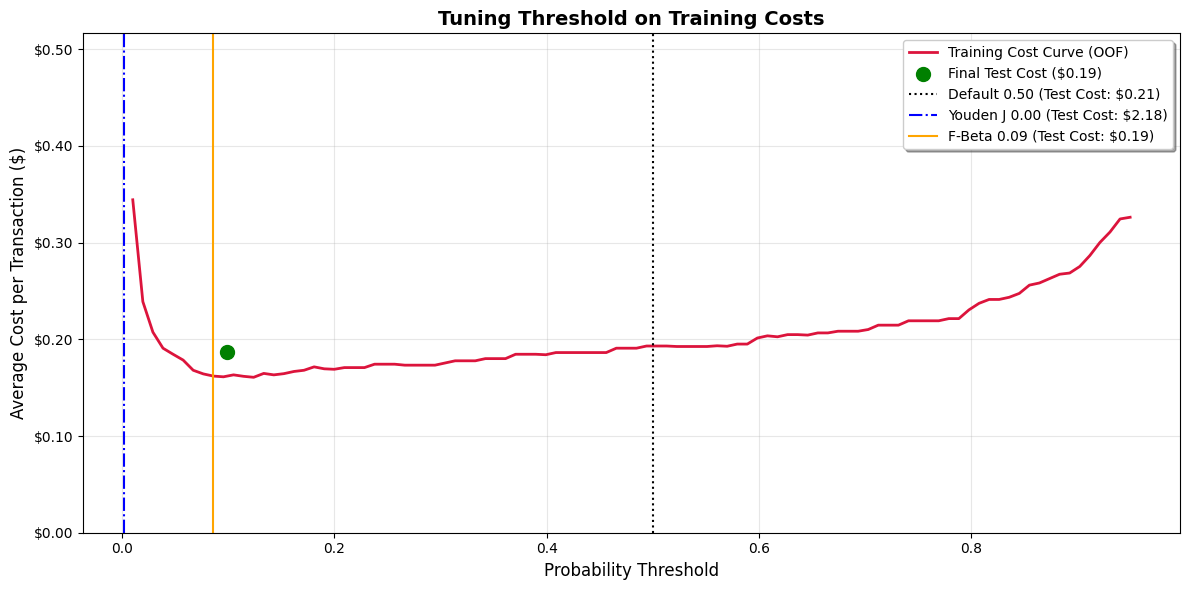

Profitability Analysis on TEST SET (per 1,000 transactions):
Using Default (0.50):    $206
Using Business Tuned:    $187
Potential Savings:       $19


In [20]:
from matplotlib.ticker import StrMethodFormatter

# 1. Calculate the Cost Curve on TRAINING OOF Data
train_thresholds = np.linspace(0.01, 0.95, 100)
train_costs_per_capita = []

for t in train_thresholds:
    y_pred_t = (oof_train_probs >= t).astype(int)
    fp = ((y_pred_t == 1) & (y_train == 0)).sum()
    fn = ((y_pred_t == 0) & (y_train == 1)).sum()
    avg_cost = ((fp * COST_FP) + (fn * COST_FN)) / len(y_train)
    train_costs_per_capita.append(avg_cost)

# 2. Helper function to get cost on TEST data for evaluation
def get_test_cost_per_capita(threshold):
    y_p = (y_proba >= threshold).astype(int)
    fp = ((y_p == 1) & (y_test == 0)).sum()
    fn = ((y_p == 0) & (y_test == 1)).sum()
    return ((fp * COST_FP) + (fn * COST_FN)) / len(y_test)

cost_default = get_test_cost_per_capita(0.50)
cost_youden  = get_test_cost_per_capita(optimal_j_threshold)
cost_fbeta   = get_test_cost_per_capita(best_threshold_f_beta)
cost_business = get_test_cost_per_capita(cost_optimal_threshold)

# 3. PLOTTING
plt.figure(figsize=(12, 6))
plt.plot(train_thresholds, train_costs_per_capita, color='crimson', lw=2, label='Training Cost Curve (OOF)')

# Mark the test performance of our tuned threshold
plt.scatter([cost_optimal_threshold], [cost_business], color='green', s=100, zorder=5, label=f'Final Test Cost (${cost_business:.2f})')

# Add Vertical Lines for Candidate Thresholds
plt.axvline(x=0.50, color='black', linestyle=':', label=f'Default 0.50 (Test Cost: ${cost_default:.2f})')
plt.axvline(x=optimal_j_threshold, color='blue', linestyle='-.', label=f'Youden J {optimal_j_threshold:.2f} (Test Cost: ${cost_youden:.2f})')
plt.axvline(x=best_threshold_f_beta, color='orange', linestyle='-', label=f'F-Beta {best_threshold_f_beta:.2f} (Test Cost: ${cost_fbeta:.2f})')

plt.title('Tuning Threshold on Training Costs', fontsize=14, fontweight='bold')
plt.xlabel('Probability Threshold', fontsize=12)
plt.ylabel('Average Cost per Transaction ($)', fontsize=12)
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.2f}'))
plt.ylim(0, max(train_costs_per_capita) * 1.5) # Zoom in to the valley
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

print(f"Profitability Analysis on TEST SET (per 1,000 transactions):")
print(f"Using Default (0.50):    ${cost_default * 1000:,.0f}")
print(f"Using Business Tuned:    ${cost_business * 1000:,.0f}")
print(f"Potential Savings:       ${(cost_default - cost_business) * 1000:,.0f}")

### The "Generalization Gap" (Green vs. Orange)
*   Notice that the Tuned threshold (Green) was derived entirely from Training OOF data.
*   The test performance (marked as points) shows how well these thresholds generalized to the holdout set.
*   **The Business Reality:** The "Valley" of the training curve is very flat between 0.05 and 0.30. This means the model is "robust"—small errors in threshold selection don't cause major financial losses.

## Implications of Data-Driven and Business-Driven Thresholds

Our results show that thresholds calculated by standard statistical formulas may not align with business objectives when the dataset is severely imbalanced.

* **Default (0.50):** Too conservative for this problem. The probability distribution visualization earlier showed that the model assigns very low scores to most fraudulent transactions — it rarely outputs probabilities above 0.5 for fraud — so the default threshold misses the majority of cases.

* **Youden's J (~0.001):** This is the most instructive result in the notebook, and it deserves a careful explanation. Youden's J maximizes TPR − FPR, treating both error types as equally costly. On a 99.8% / 0.2% dataset, the FPR denominator (all actual negatives) contains over 85,000 legitimate transactions. Even if the model flags thousands of them as fraud, the FPR barely moves — the massive TN pool absorbs the false positives. As a result, J keeps climbing as the threshold is lowered, all the way down to near zero, at which point almost every transaction is flagged as fraud. The cost curve shows the consequence: a flood of false positives drives total cost far above the default threshold. This is Youden's J working exactly as designed — the problem is that its equal-cost assumption is fundamentally wrong for fraud detection.

* **F-Beta Optimal (~0.09):** By weighting recall 4× higher (β = 2), we find a threshold that catches substantially more fraud than the default while keeping false positives manageable. This outperforms both the default and Youden's J under our cost assumptions.

* **Cost-Optimal (~0.10):** Explicitly incorporating the $100 FP and $450 FN costs selects a threshold in a similar range to F-Beta, but chosen to minimize total dollar loss directly. This is the most defensible approach for a business context — but it requires honest, well-estimated cost inputs.

Statistical methods like Youden's J optimize mathematical metrics; cost-based methods align with business outcomes. On highly imbalanced data, these can produce radically different — and in Youden's J's case, catastrophically wrong — thresholds.

---

### What Comes Next: Hyperparameter Tuning

We have optimized the decision threshold for a given model. But we have not yet asked whether the model itself is as good as it could be. Different hyperparameters might produce better probability separations, which could then be paired with a new cost-optimal threshold.

Notebook 6 addresses this with GridSearchCV hyperparameter tuning. One critical design decision: we **cannot** use cost-based threshold scoring inside GridSearch, because the optimal threshold changes with every set of hyperparameters being evaluated. Plugging in a hardcoded threshold creates circular logic — the search would favor models that happen to score well at *that specific threshold* rather than models that are genuinely better at separating classes. Instead, notebook 6 uses PR-AUC (a threshold-independent metric) to select the best model, then applies cost-based threshold tuning separately afterward.